🔍 organized_by_sensor 데이터 분포 분석 시작...
발견된 센서 폴더: 7개
  - AGS_Green_풍향풍속
  - AGS_Green_8동_온습도_입구근처20M
  - AGS_Green_7동_온습도_입구근처20M
  - AGS_Green_7동_모터제어
  - AGS_Green_외부온습도
  - AGS_Green_강우
  - AGS_Green_8동_모터제어

분석 중: AGS_Green_풍향풍속
파일 수: 2개

📊 기본 정보:
  총 데이터 행 수: 51,138
  컬럼: ['ts', 'site_id', 'sensor_id', 'wind_speed', 'wind_direction', 'facility_id']
  시간 범위: 2026-02-11 00:00:02.903000+00:00 ~ 2026-03-11 23:58:51.189000+00:00
  수치형 컬럼: ['wind_speed', 'wind_direction', 'facility_id']

📈 wind_speed 분포 분석:
  평균: 1.47
  표준편차: 1.43
  최소값: 0.00
  최대값: 11.90
  중앙값: 1.10
  결측치: 0개 (0.00%)
  이상치: 3784개 (7.40%)
  고유값: 112개

📈 wind_direction 분포 분석:
  평균: 172.60
  표준편차: 101.54
  최소값: 0.00
  최대값: 359.00
  중앙값: 184.00
  결측치: 0개 (0.00%)
  이상치: 0개 (0.00%)
  고유값: 360개

📈 facility_id 분포 분석:
  평균: nan
  표준편차: nan
  최소값: nan
  최대값: nan
  중앙값: nan
  결측치: 51,138개 (100.00%)
  이상치: 0개 (0.00%)
  고유값: 0개

분석 중: AGS_Green_8동_온습도_입구근처20M
파일 수: 2개

📊 기본 정보:
  총 데이터 행 수: 51,136
  컬럼: ['ts', 'site_id', 'sensor_id'

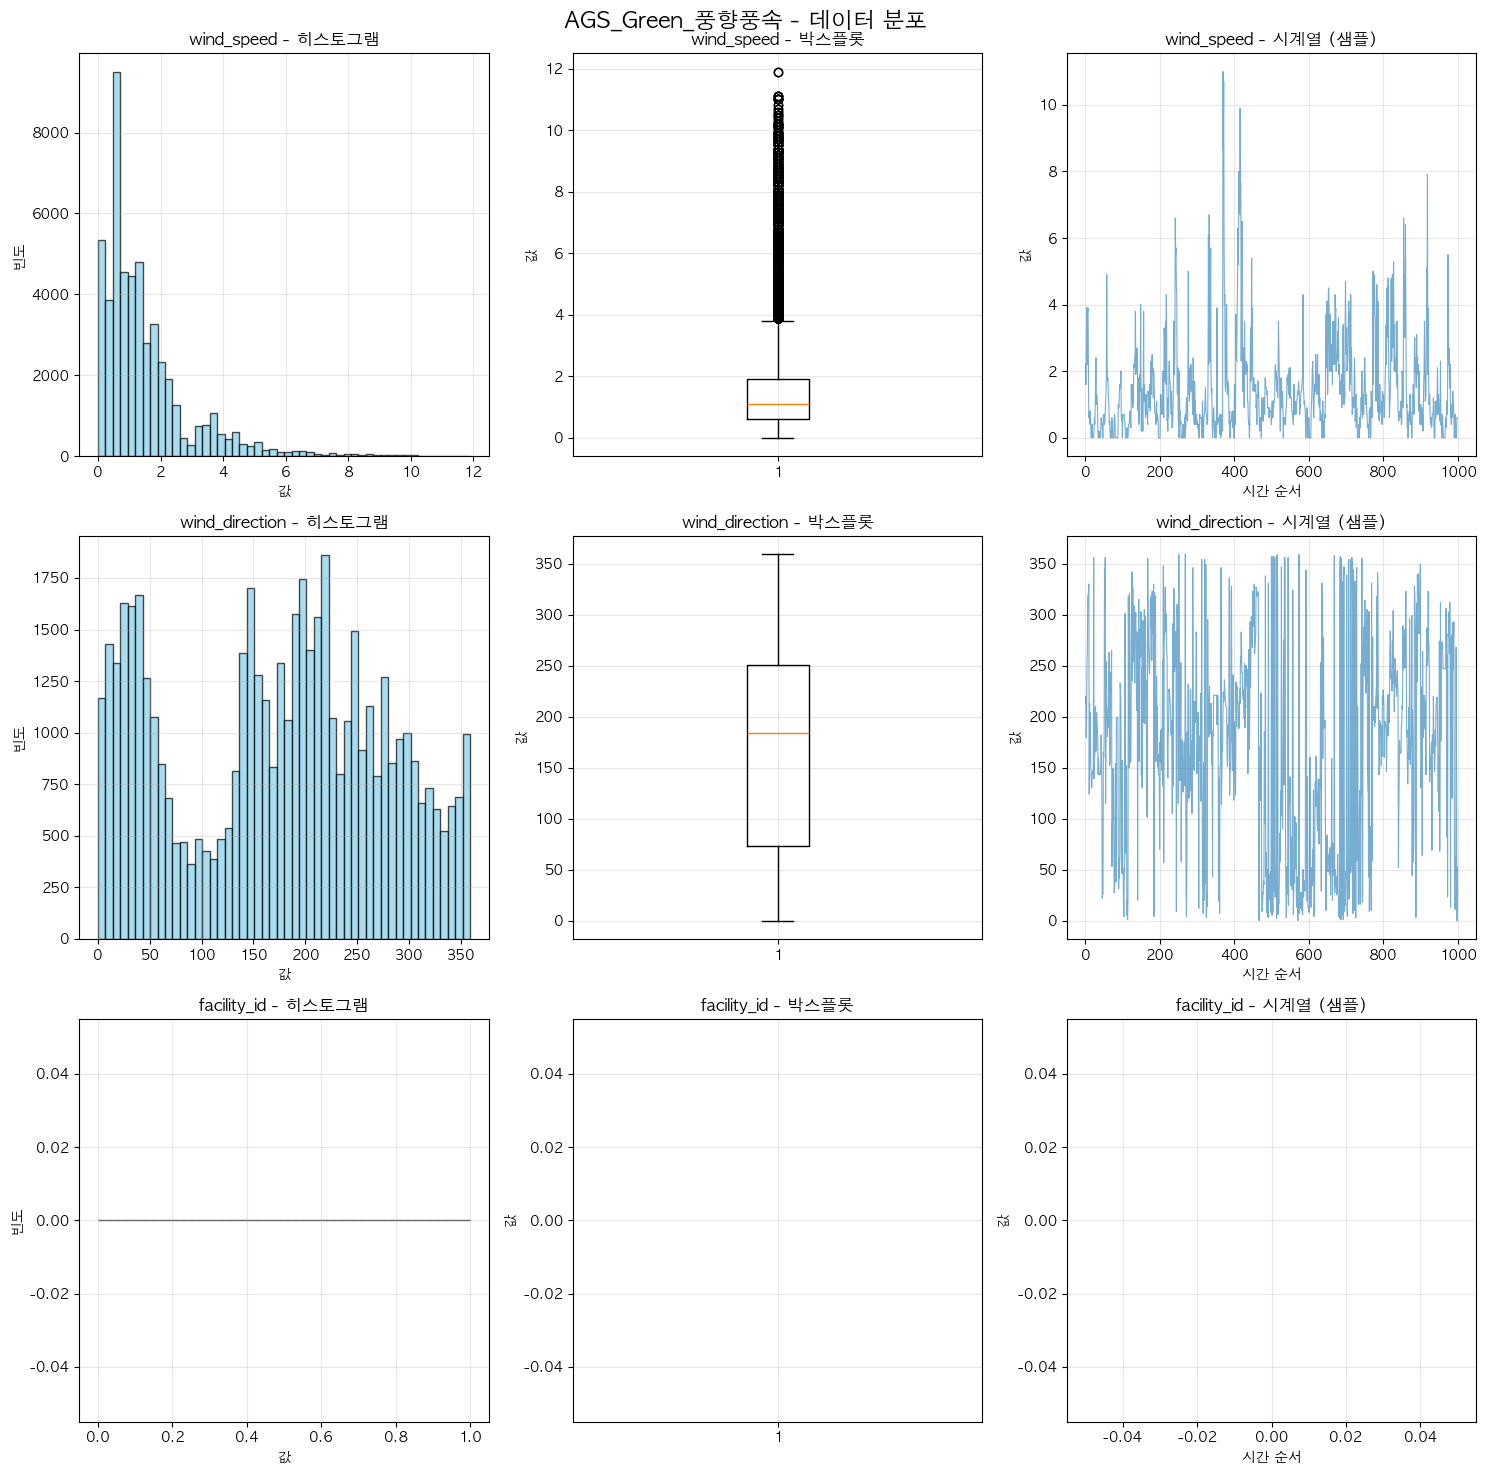

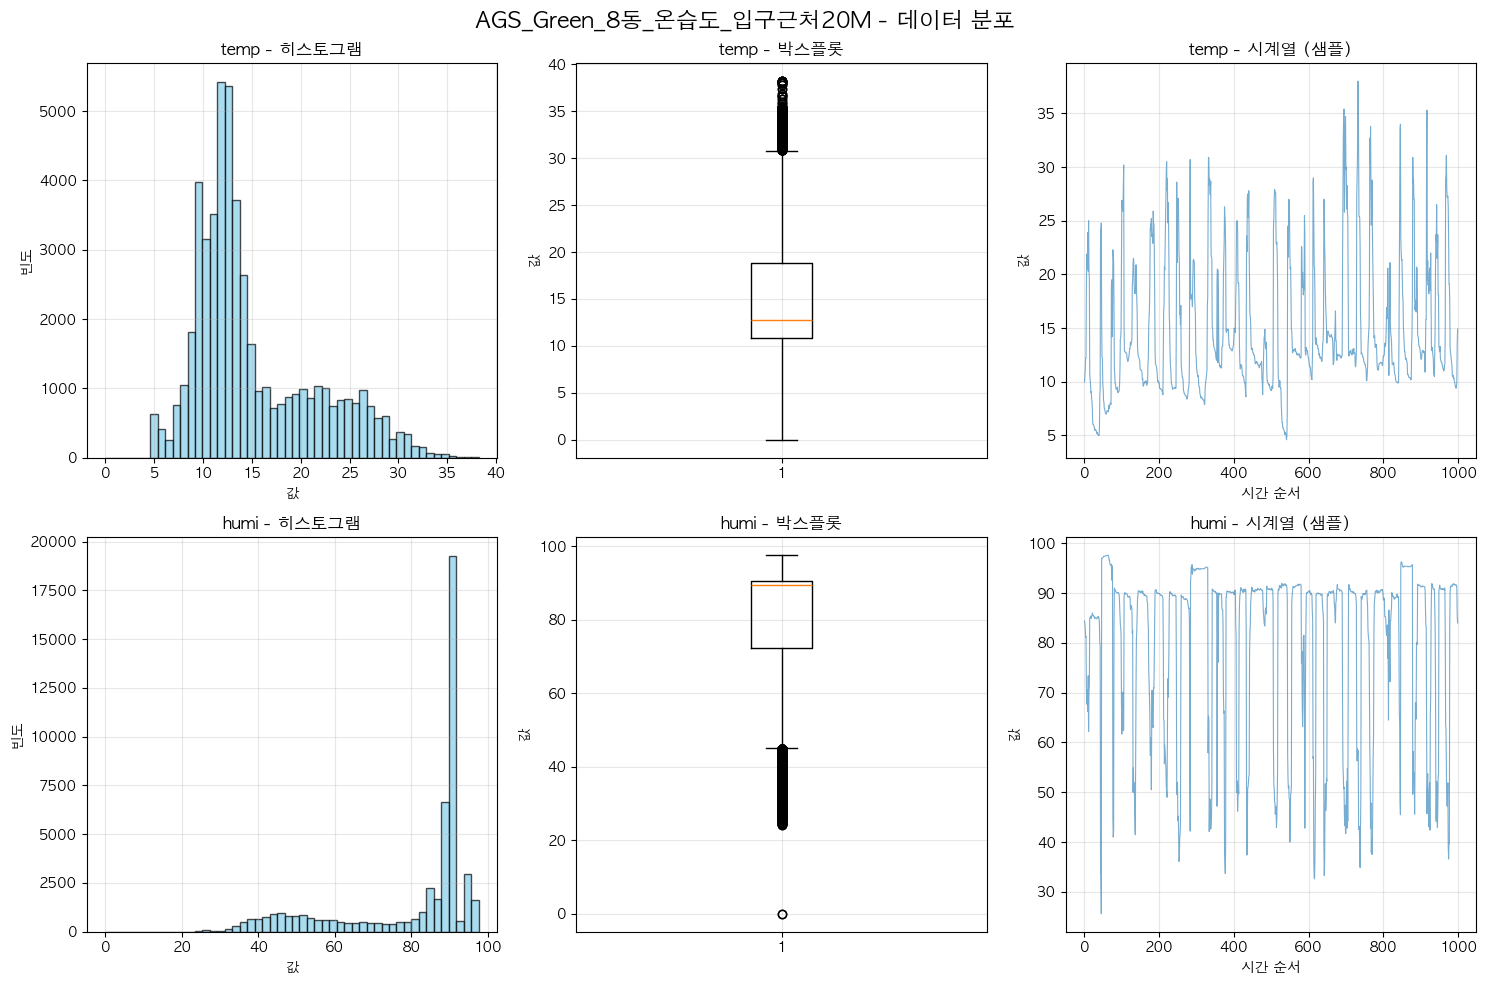

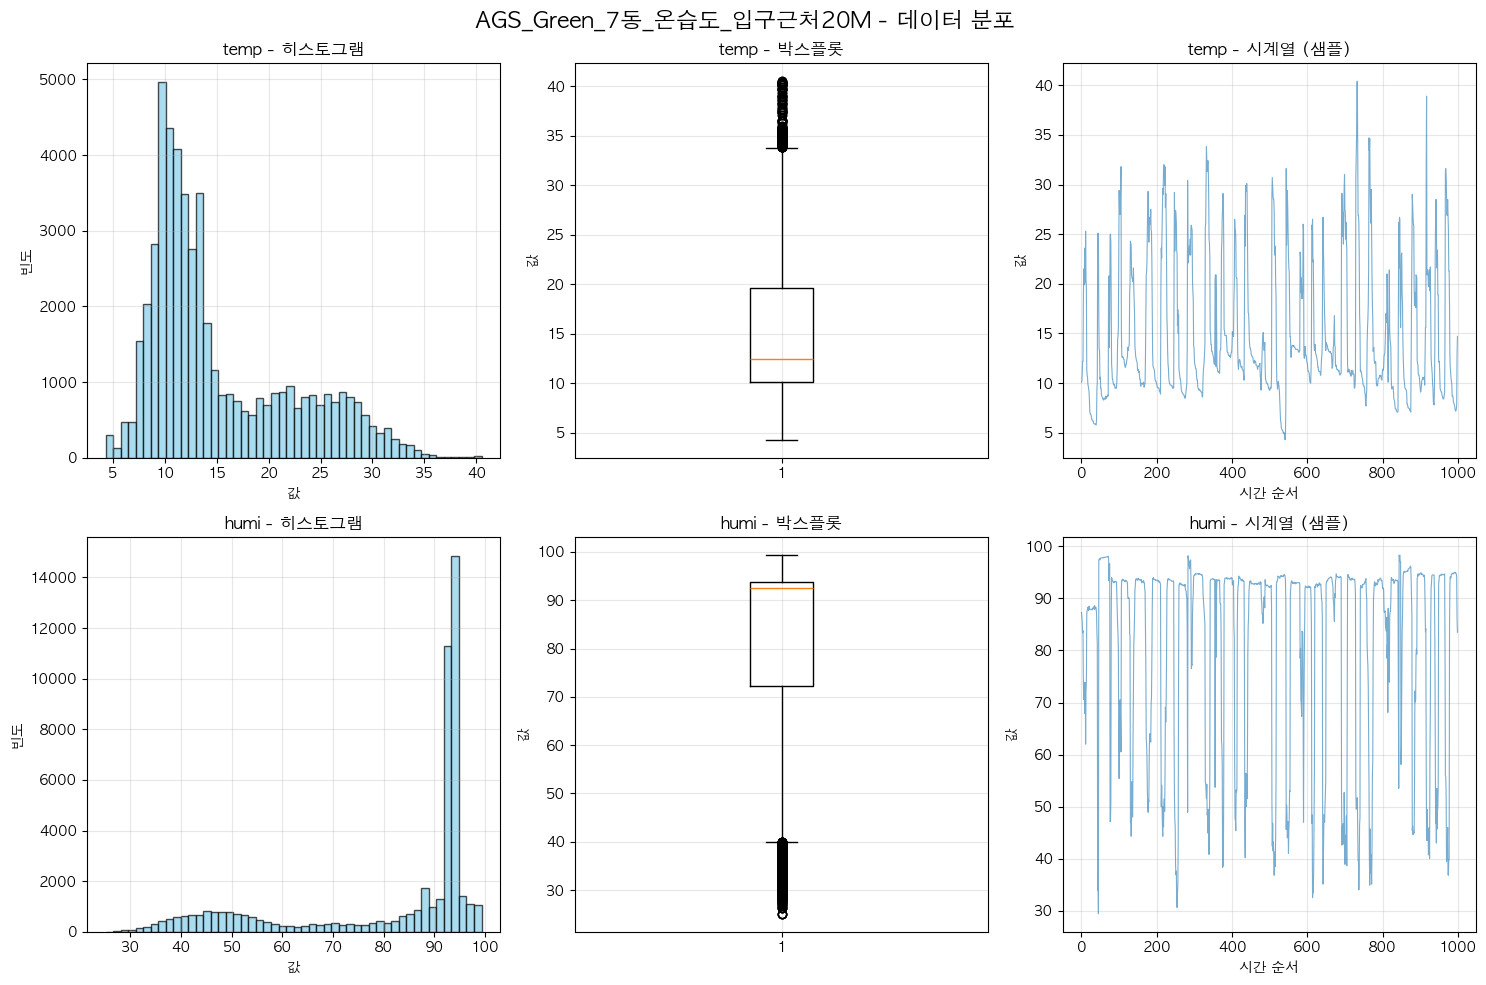

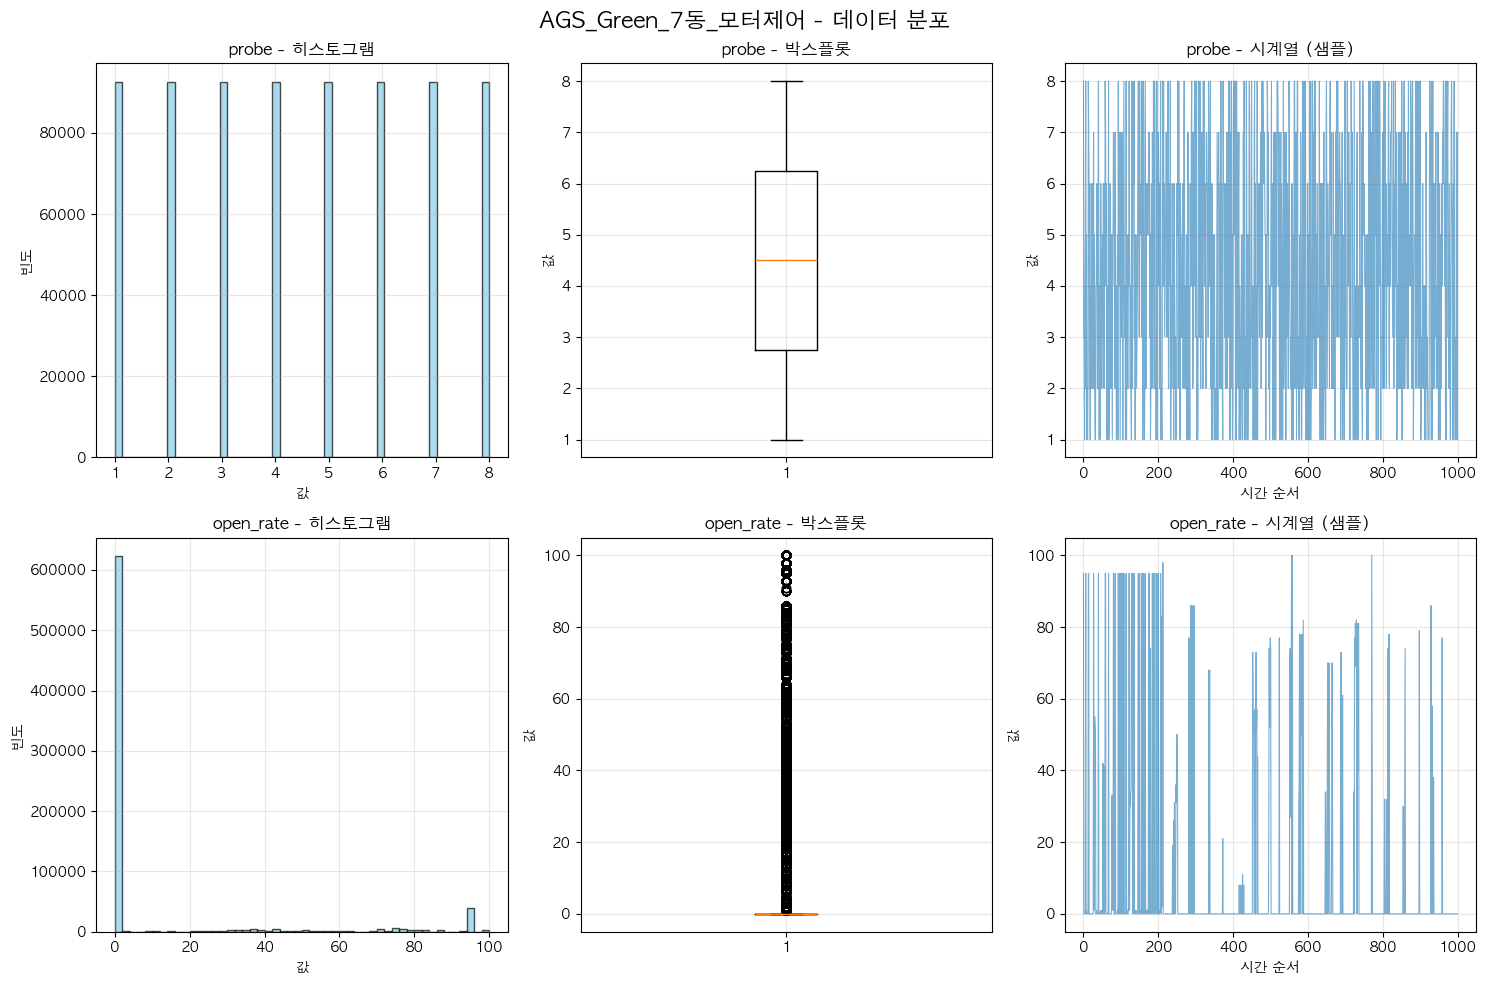

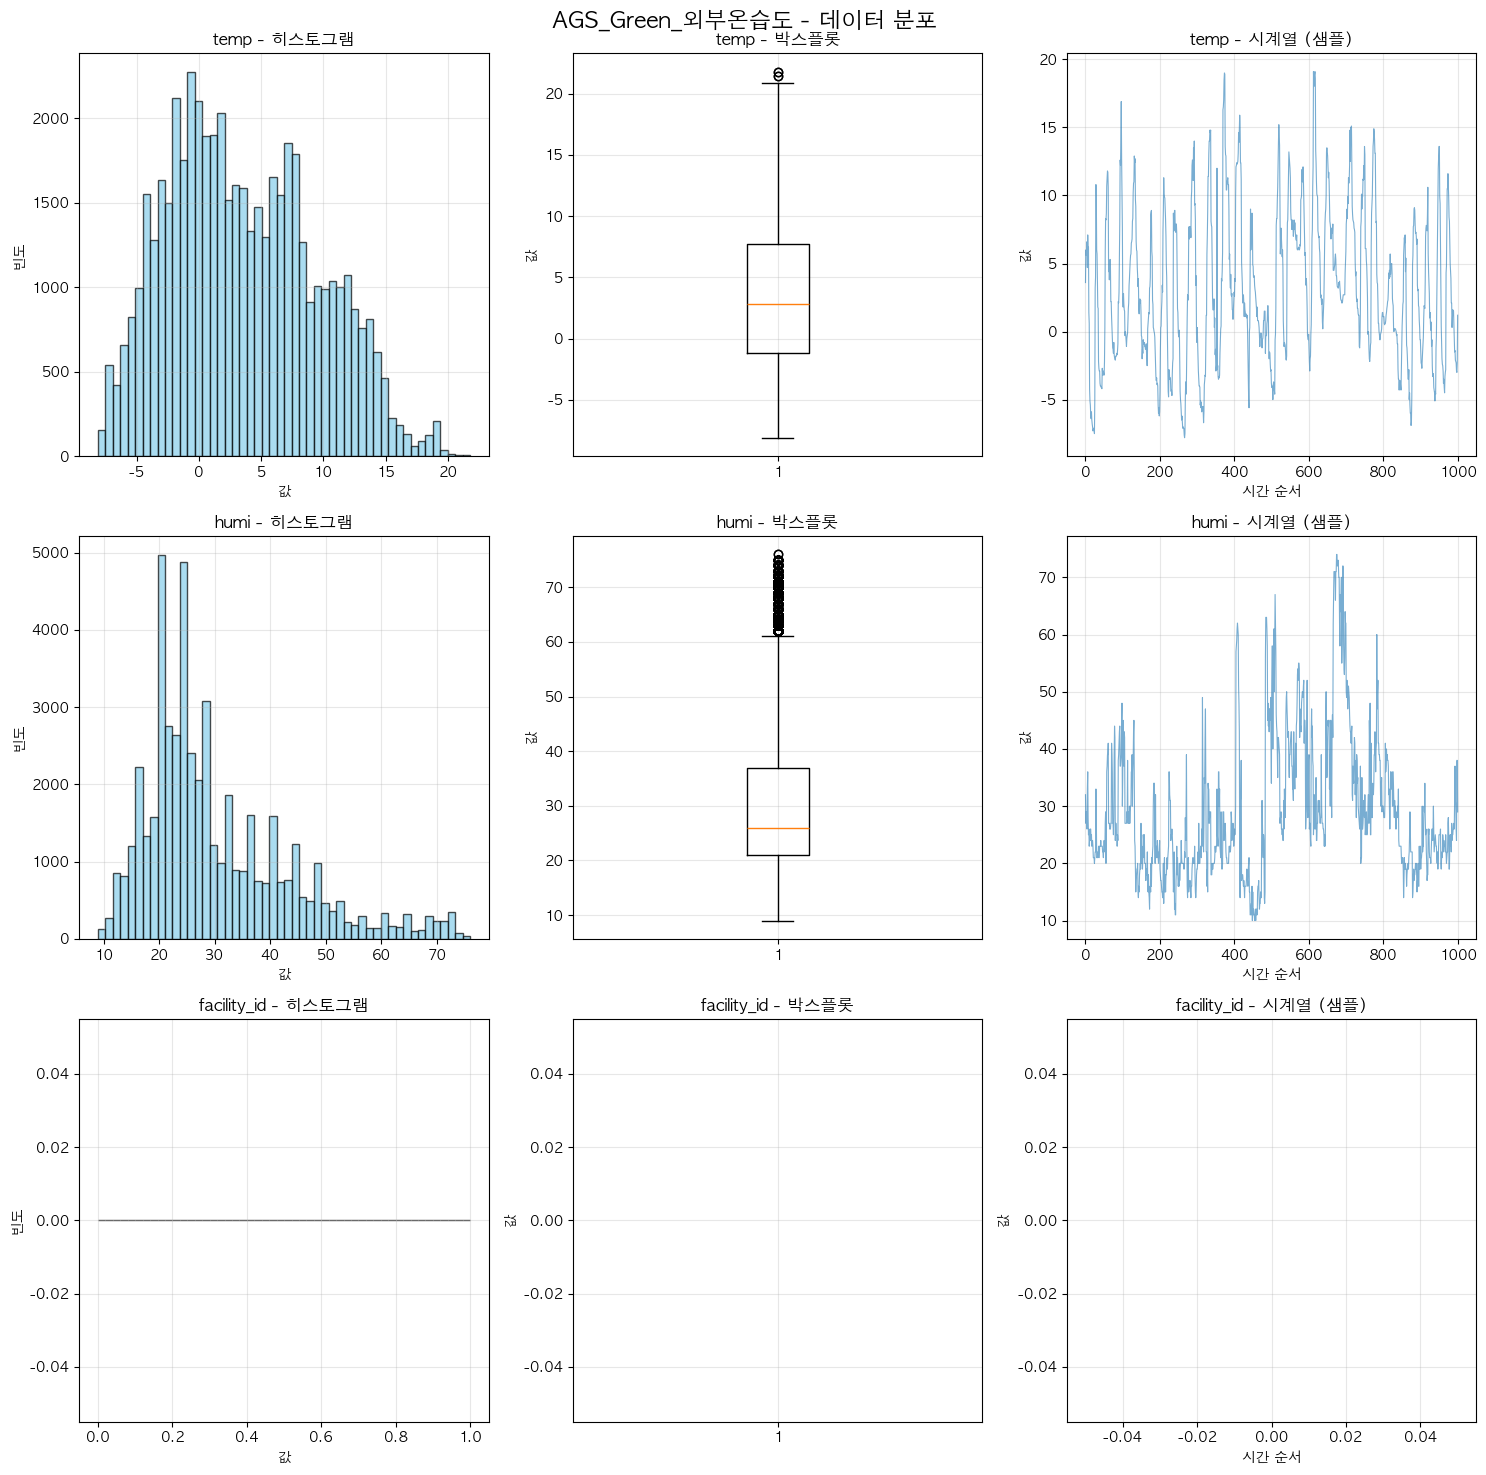

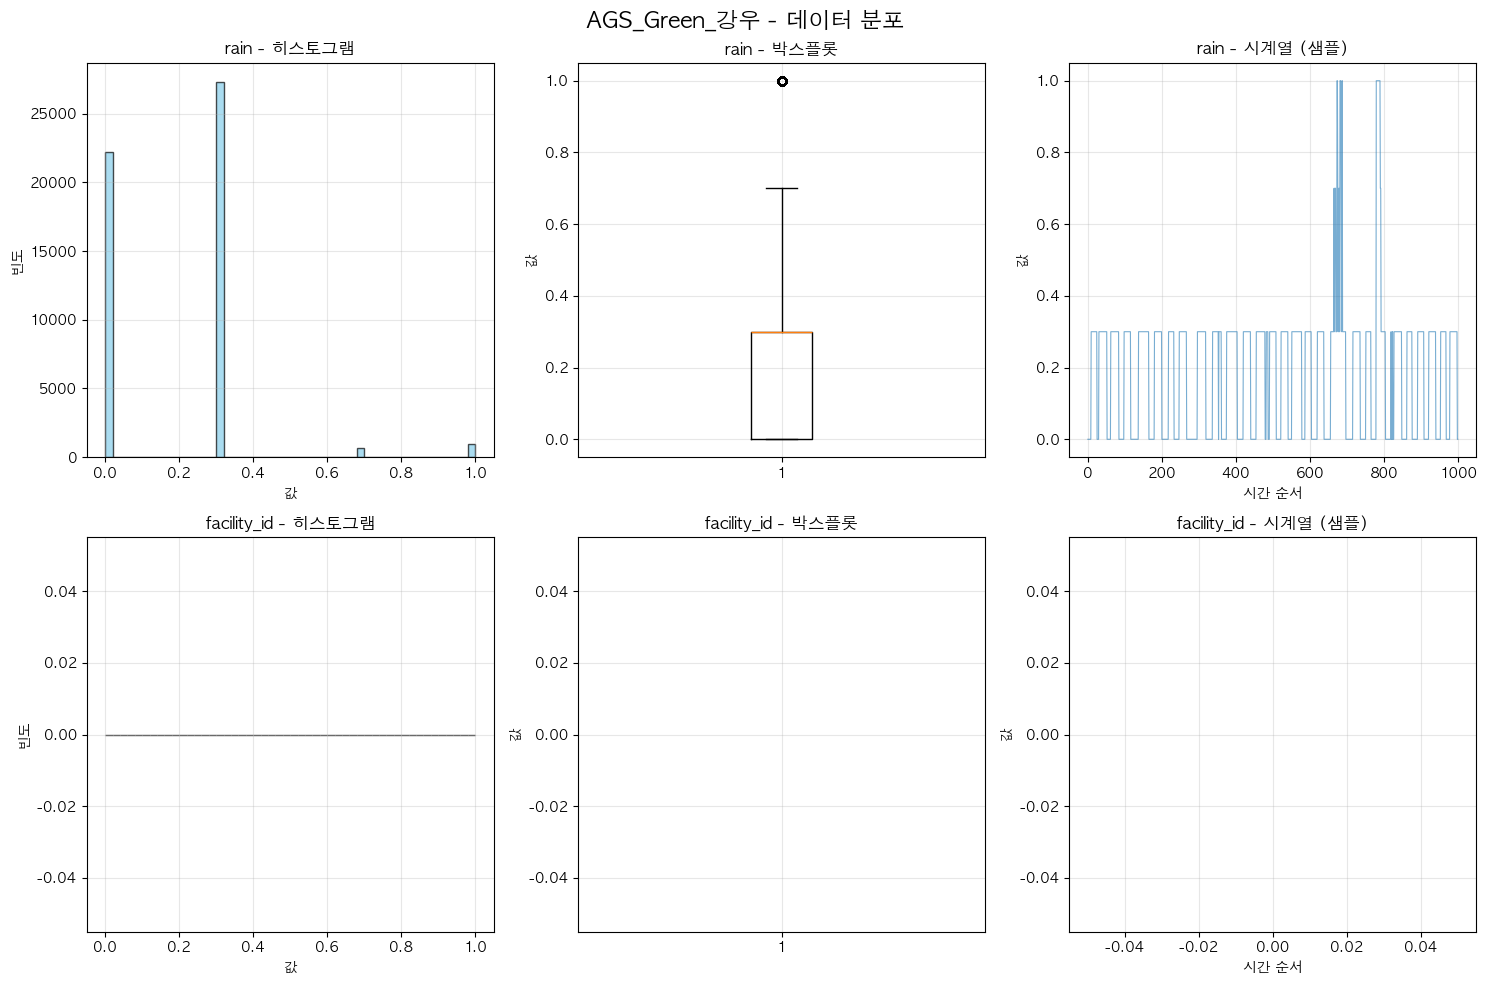

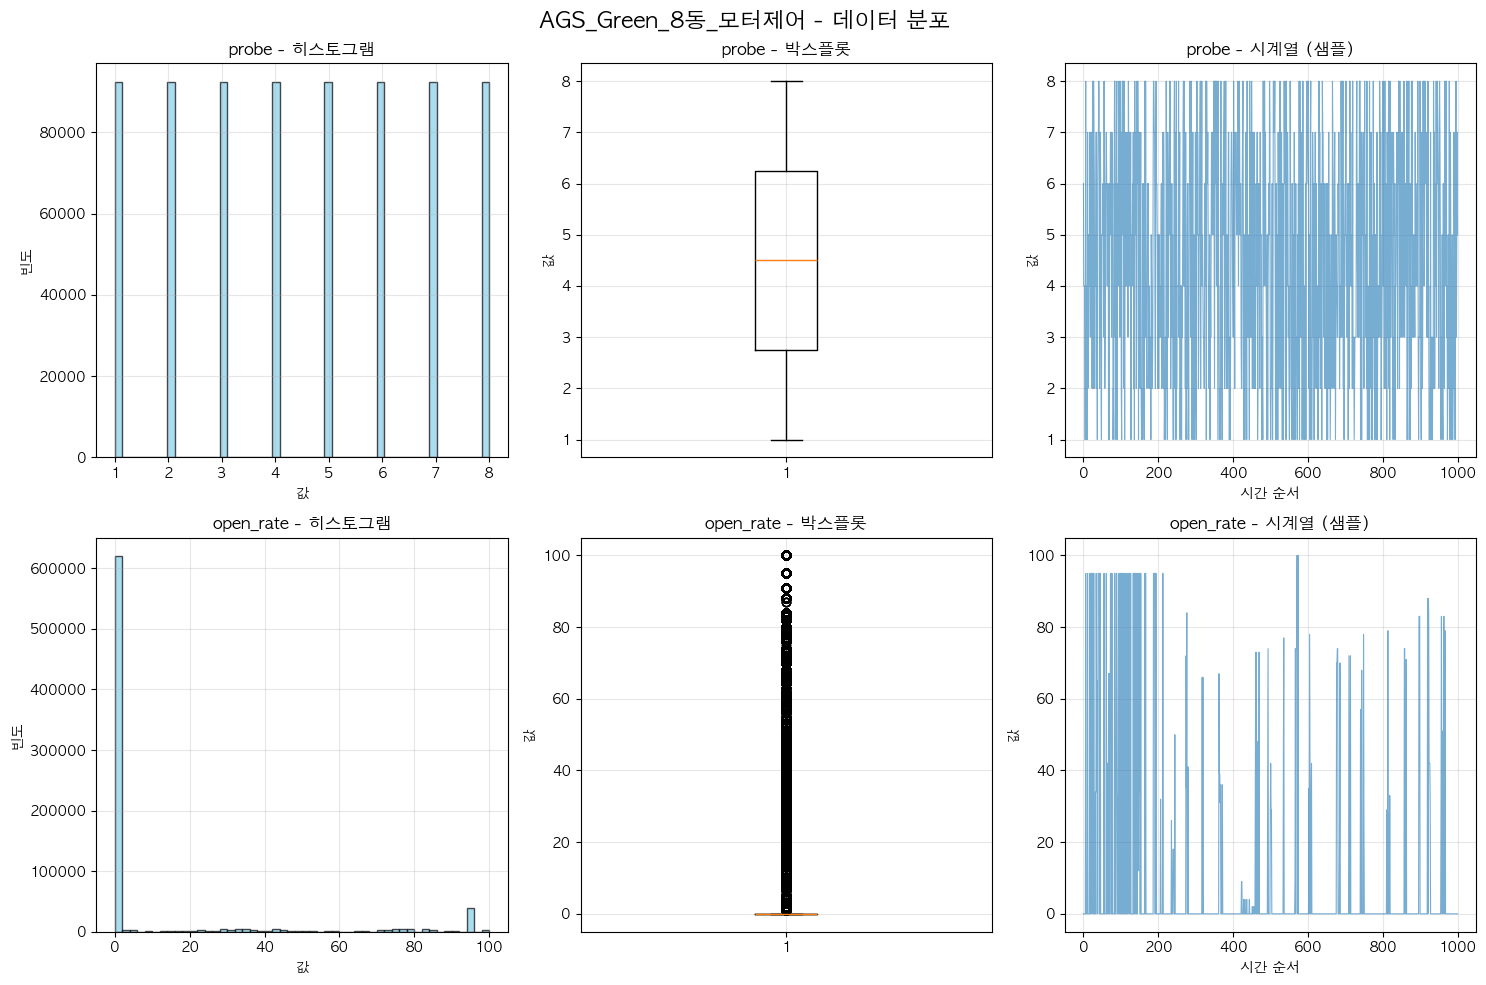


📋 전체 센서 데이터 요약


,센서,컬럼,데이터수,평균,표준편차,최소값,최대값,중앙값,결측치_개수,결측치_비율(%),이상치_개수,이상치_비율(%),고유값_개수
0,AGS_Green_풍향풍속,wind_speed,51138,1.47,1.43,0.00,11.90,1.10,0,0.00,3784,7.40,112
1,AGS_Green_풍향풍속,wind_direction,51138,172.60,101.54,0.00,359.00,184.00,0,0.00,0,0.00,360
2,AGS_Green_풍향풍속,facility_id,51138,nan,nan,nan,nan,nan,51138,100.00,0,0.00,0
3,AGS_Green_8동_온습도...,temp,51136,15.06,6.20,0.00,38.20,12.80,0,0.00,744,1.45,320
4,AGS_Green_8동_온습도...,humi,51136,79.91,17.82,0.00,97.60,89.60,0,0.00,4084,7.99,713
5,AGS_Green_7동_온습도...,temp,51136,15.10,6.86,4.30,40.50,12.50,0,0.00,262,0.51,341
6,AGS_Green_7동_온습도...,humi,51136,81.31,19.43,25.10,99.30,92.60,0,0.00,2320,4.54,719
7,AGS_Green_7동_모터제어,probe,740432,4.50,2.29,1.00,8.00,4.50,0,0.00,0,0.00,8
8,AGS_Green_7동_모터제어,open_rate,740432,10.89,27.26,0.00,100.00,0.00,0,0.00,137602,18.58,93
9,AGS_Green_외부온습도,temp,51138,3.49,5.92,-8.10,21.80,2.80,0,0.00,4,0.01,291



✅ 분석 완료!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터가 있는 기본 경로
base_path = "/Users/jeong-won-il/workspace/SDF/train/pipeline_output/organized_by_sensor"

def analyze_sensor_data_distribution():
    """
    organized_by_sensor 폴더 내의 모든 센서 데이터에 대한 분포 분석
    """
    
    # 1. 센서 폴더 목록 가져오기
    sensor_folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
    print(f"발견된 센서 폴더: {len(sensor_folders)}개")
    for folder in sensor_folders:
        print(f"  - {folder}")
    
    # 2. 각 센서 폴더별 데이터 분석
    all_results = {}
    
    for sensor_folder in sensor_folders:
        folder_path = os.path.join(base_path, sensor_folder)
        csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
        
        if not csv_files:
            continue
            
        print(f"\n{'='*60}")
        print(f"분석 중: {sensor_folder}")
        print(f"파일 수: {len(csv_files)}개")
        print(f"{'='*60}")
        
        # 해당 센서의 모든 CSV 파일 읽기
        sensor_data = []
        for csv_file in csv_files:
            try:
                df = pd.read_csv(csv_file)
                sensor_data.append(df)
            except Exception as e:
                print(f"  파일 읽기 오류 ({csv_file}): {e}")
        
        if not sensor_data:
            continue
            
        # 모든 데이터 합치기
        combined_df = pd.concat(sensor_data, ignore_index=True)
        
        # 기본 정보 출력
        print(f"\n📊 기본 정보:")
        print(f"  총 데이터 행 수: {len(combined_df):,}")
        print(f"  컬럼: {list(combined_df.columns)}")
        print(f"  시간 범위: {combined_df['ts'].min()} ~ {combined_df['ts'].max()}")
        
        # 수치형 컬럼 찾기
        numeric_cols = combined_df.select_dtypes(include=[np.number]).columns.tolist()
        print(f"  수치형 컬럼: {numeric_cols}")
        
        # 각 수치형 컬럼에 대한 분포 분석
        sensor_analysis = {}
        
        for col in numeric_cols:
            print(f"\n📈 {col} 분포 분석:")
            
            # 기본 통계
            stats = combined_df[col].describe()
            print(f"  평균: {stats['mean']:.2f}")
            print(f"  표준편차: {stats['std']:.2f}")
            print(f"  최소값: {stats['min']:.2f}")
            print(f"  최대값: {stats['max']:.2f}")
            print(f"  중앙값: {stats['50%']:.2f}")
            
            # 결측치 확인
            missing_count = combined_df[col].isnull().sum()
            missing_pct = (missing_count / len(combined_df)) * 100
            print(f"  결측치: {missing_count:,}개 ({missing_pct:.2f}%)")
            
            # 이상치 확인 (IQR 방식)
            Q1 = combined_df[col].quantile(0.25)
            Q3 = combined_df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers = combined_df[(combined_df[col] < lower_bound) | (combined_df[col] > upper_bound)][col]
            print(f"  이상치: {len(outliers)}개 ({(len(outliers)/len(combined_df))*100:.2f}%)")
            
            # 고유값 개수
            unique_count = combined_df[col].nunique()
            print(f"  고유값: {unique_count:,}개")
            
            # 분석 결과 저장
            sensor_analysis[col] = {
                'stats': stats,
                'missing_count': missing_count,
                'missing_pct': missing_pct,
                'outliers_count': len(outliers),
                'outliers_pct': (len(outliers)/len(combined_df))*100,
                'unique_count': unique_count,
                'data': combined_df[col].dropna()
            }
        
        all_results[sensor_folder] = {
            'total_rows': len(combined_df),
            'columns': list(combined_df.columns),
            'numeric_cols': numeric_cols,
            'analysis': sensor_analysis,
            'raw_data': combined_df
        }
    
    return all_results

def create_distribution_plots(all_results):
    """
    각 센서 데이터의 분포를 시각화
    """
    
    # 전체 플롯을 위한 설정
    total_sensors = len(all_results)
    fig_rows = total_sensors
    fig_cols = 1
    
    # 각 센서별로 플롯 생성
    for sensor_name, sensor_data in all_results.items():
        numeric_cols = sensor_data['numeric_cols']
        
        if not numeric_cols:
            continue
            
        # 센서별 플롯 생성
        n_cols = len(numeric_cols)
        fig, axes = plt.subplots(n_cols, 3, figsize=(15, 5*n_cols))
        if n_cols == 1:
            axes = axes.reshape(1, -1)
        
        fig.suptitle(f'{sensor_name} - 데이터 분포', fontsize=16, fontweight='bold')
        
        for i, col in enumerate(numeric_cols):
            data = sensor_data['analysis'][col]['data']
            
            # 1. 히스토그램
            axes[i, 0].hist(data, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
            axes[i, 0].set_title(f'{col} - 히스토그램')
            axes[i, 0].set_xlabel('값')
            axes[i, 0].set_ylabel('빈도')
            axes[i, 0].grid(True, alpha=0.3)
            
            # 2. 박스플롯
            axes[i, 1].boxplot(data, vert=True)
            axes[i, 1].set_title(f'{col} - 박스플롯')
            axes[i, 1].set_ylabel('값')
            axes[i, 1].grid(True, alpha=0.3)
            
            # 3. 시계열 (샘플링)
            raw_data = sensor_data['raw_data']
            if len(raw_data) > 1000:
                sample_data = raw_data.sample(1000, random_state=42).sort_values('ts')
            else:
                sample_data = raw_data.sort_values('ts')
            
            axes[i, 2].plot(range(len(sample_data)), sample_data[col], alpha=0.6, linewidth=0.8)
            axes[i, 2].set_title(f'{col} - 시계열 (샘플)')
            axes[i, 2].set_xlabel('시간 순서')
            axes[i, 2].set_ylabel('값')
            axes[i, 2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

def create_summary_table(all_results):
    """
    모든 센서 데이터의 요약 테이블 생성
    """
    
    summary_data = []
    
    for sensor_name, sensor_data in all_results.items():
        for col_name, col_analysis in sensor_data['analysis'].items():
            stats = col_analysis['stats']
            
            summary_data.append({
                '센서': sensor_name,
                '컬럼': col_name,
                '데이터수': sensor_data['total_rows'],
                '평균': f"{stats['mean']:.2f}",
                '표준편차': f"{stats['std']:.2f}",
                '최소값': f"{stats['min']:.2f}",
                '최대값': f"{stats['max']:.2f}",
                '중앙값': f"{stats['50%']:.2f}",
                '결측치_개수': col_analysis['missing_count'],
                '결측치_비율(%)': f"{col_analysis['missing_pct']:.2f}",
                '이상치_개수': col_analysis['outliers_count'],
                '이상치_비율(%)': f"{col_analysis['outliers_pct']:.2f}",
                '고유값_개수': col_analysis['unique_count']
            })
    
    summary_df = pd.DataFrame(summary_data)
    
    print("\n" + "="*120)
    print("📋 전체 센서 데이터 요약")
    print("="*120)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', 20)
    display(summary_df)
    
    return summary_df

# 메인 분석 실행
print("🔍 organized_by_sensor 데이터 분포 분석 시작...")
print("="*60)

# 분석 실행
results = analyze_sensor_data_distribution()

# 시각화
print("\n📊 분포 시각화 생성...")
create_distribution_plots(results)

# 요약 테이블
summary_df = create_summary_table(results)

print("\n✅ 분석 완료!")

🔬 추가 분석 시작...

🔬 센서별 특성 심층 분석

🎯 AGS_Green_풍향풍속
--------------------------------------------------
⏰ 시간 간격 분석:
  평균 간격: 49.00초
  최소 간격: -2505528.29초
  최대 간격: 7216.93초
  표준편차: 11080.74초
  데이터 규칙성: 불규칙적

📊 wind_speed 상세 분석:
  왜도(Skewness): 2.11
  첨도(Kurtosis): 6.03
  분포 형태: 오른쪽으로 치우침
  변동계수(CV): 96.70%
  변동성: 변동성 큼

📊 wind_direction 상세 분석:
  왜도(Skewness): -0.09
  첨도(Kurtosis): -1.09
  분포 형태: 정규분포에 가까움
  변동계수(CV): 58.83%
  변동성: 변동성 큼

📊 facility_id 상세 분석:
  왜도(Skewness): nan
  첨도(Kurtosis): nan
  분포 형태: 왼쪽으로 치우침
  변동계수(CV): nan%
  변동성: 변동성 큼

🎯 AGS_Green_8동_온습도_입구근처20M
--------------------------------------------------
⏰ 시간 간격 분석:
  평균 간격: 49.00초
  최소 간격: -2505432.22초
  최대 간격: 7216.93초
  표준편차: 11080.53초
  데이터 규칙성: 불규칙적

📊 temp 상세 분석:
  왜도(Skewness): 1.00
  첨도(Kurtosis): 0.16
  분포 형태: 오른쪽으로 치우침
  변동계수(CV): 41.19%
  변동성: 보통

📊 humi 상세 분석:
  왜도(Skewness): -1.31
  첨도(Kurtosis): 0.24
  분포 형태: 왼쪽으로 치우침
  변동계수(CV): 22.29%
  변동성: 안정적

🎯 AGS_Green_7동_온습도_입구근처20M
-----------------------------------

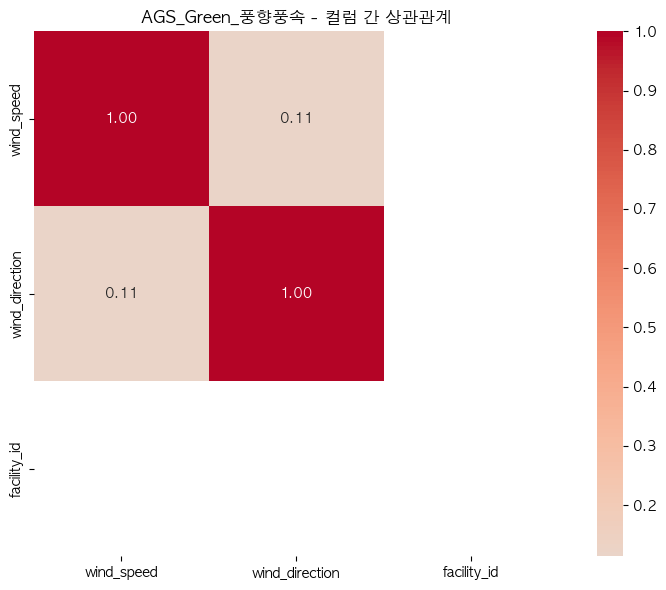

  높은 상관관계 없음 (|r| > 0.7)

📊 AGS_Green_8동_온습도_입구근처20M


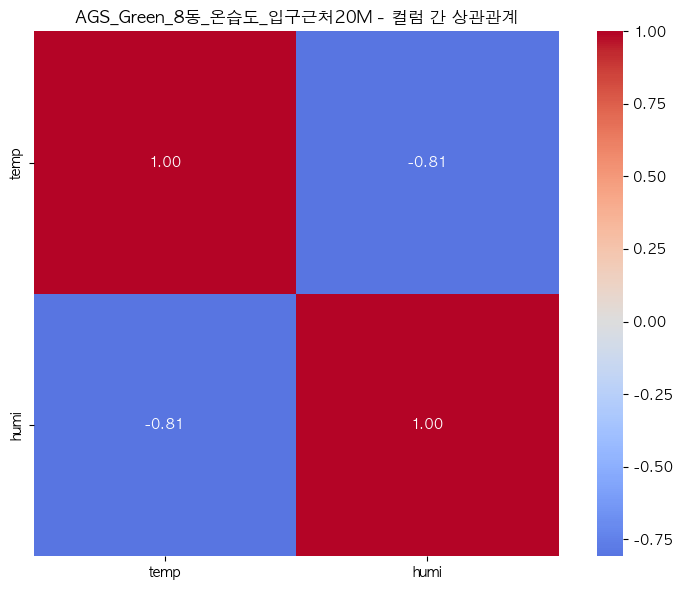

  높은 상관관계 (|r| > 0.7):
    temp ↔ humi: -0.809

📊 AGS_Green_7동_온습도_입구근처20M


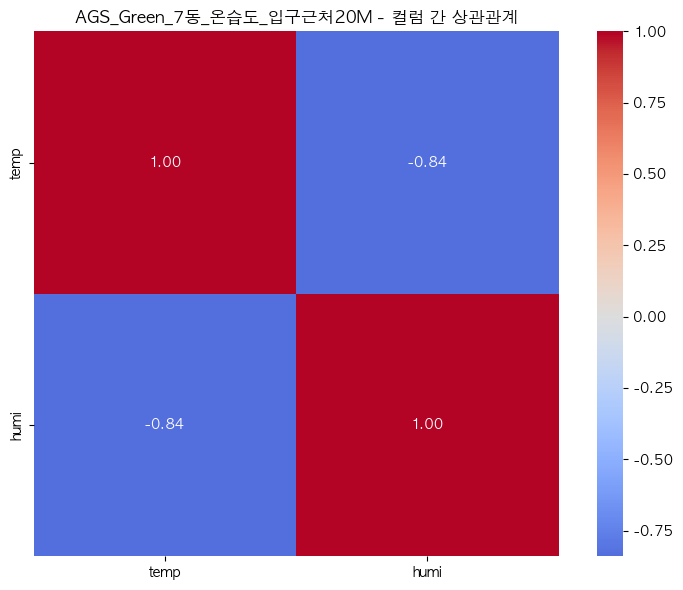

  높은 상관관계 (|r| > 0.7):
    temp ↔ humi: -0.840

📊 AGS_Green_7동_모터제어


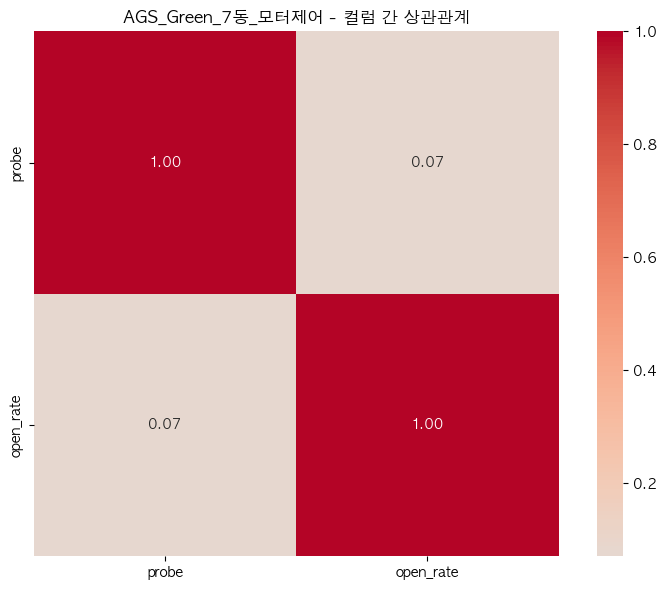

  높은 상관관계 없음 (|r| > 0.7)

📊 AGS_Green_외부온습도


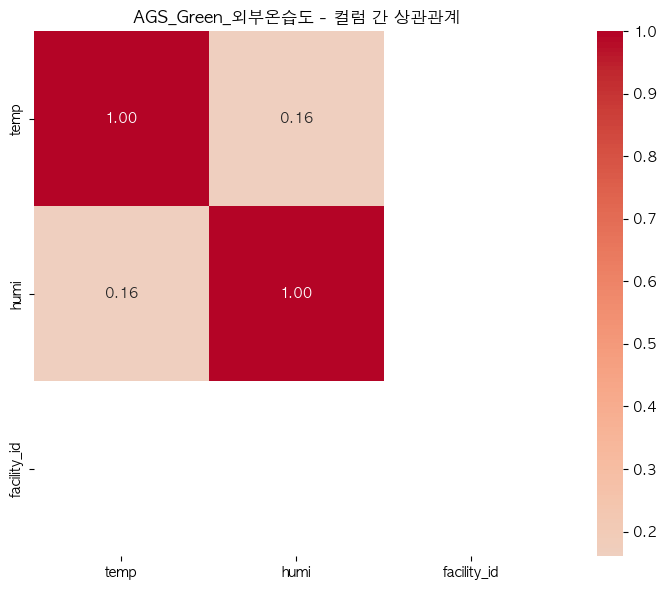

  높은 상관관계 없음 (|r| > 0.7)

📊 AGS_Green_강우


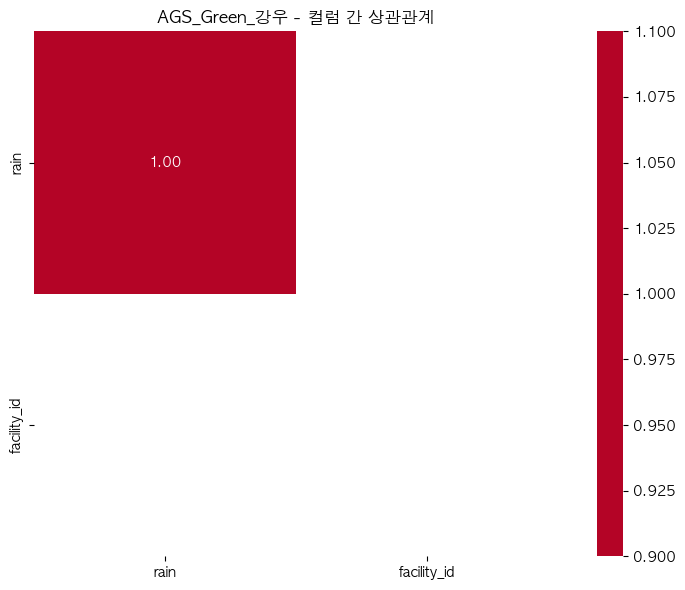

  높은 상관관계 없음 (|r| > 0.7)

📊 AGS_Green_8동_모터제어


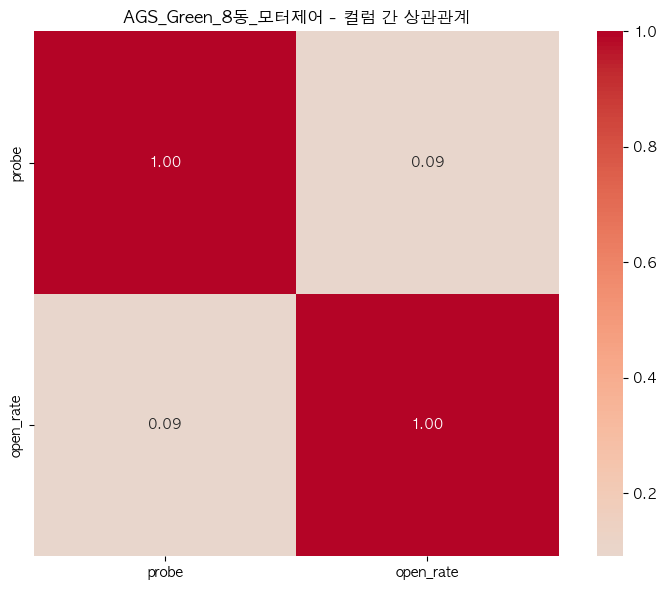

  높은 상관관계 없음 (|r| > 0.7)

✅ 심층 분석 완료!


In [3]:
# 추가 분석: 센서별 데이터 특성 심층 분석

def detailed_sensor_analysis(results):
    """
    각 센서의 특성을 더 깊이 분석
    """
    
    print("\n" + "="*80)
    print("🔬 센서별 특성 심층 분석")
    print("="*80)
    
    for sensor_name, sensor_data in results.items():
        print(f"\n🎯 {sensor_name}")
        print("-" * 50)
        
        raw_data = sensor_data['raw_data']
        
        # 시간 간격 분석 - datetime 파싱 오류 수정
        try:
            raw_data['ts'] = pd.to_datetime(raw_data['ts'], format='mixed')
        except:
            try:
                raw_data['ts'] = pd.to_datetime(raw_data['ts'], format='ISO8601')
            except:
                raw_data['ts'] = pd.to_datetime(raw_data['ts'], errors='coerce')
        
        time_diffs = raw_data['ts'].diff().dt.total_seconds().dropna()
        
        print(f"⏰ 시간 간격 분석:")
        print(f"  평균 간격: {time_diffs.mean():.2f}초")
        print(f"  최소 간격: {time_diffs.min():.2f}초")
        print(f"  최대 간격: {time_diffs.max():.2f}초")
        print(f"  표준편차: {time_diffs.std():.2f}초")
        
        # 데이터 규칙성 분석
        regular_intervals = (time_diffs.std() / time_diffs.mean()) < 0.1  # 변동계수가 10% 미만이면 규칙적
        print(f"  데이터 규칙성: {'규칙적' if regular_intervals else '불규칙적'}")
        
        # 각 수치형 컬럼에 대한 추가 분석
        for col in sensor_data['numeric_cols']:
            col_data = sensor_data['analysis'][col]
            data = col_data['data']
            
            print(f"\n📊 {col} 상세 분석:")
            
            # 데이터 분포 형태 분석
            skewness = data.skew()
            kurtosis = data.kurtosis()
            
            print(f"  왜도(Skewness): {skewness:.2f}")
            print(f"  첨도(Kurtosis): {kurtosis:.2f}")
            
            if abs(skewness) < 0.5:
                dist_shape = "정규분포에 가까움"
            elif skewness > 0.5:
                dist_shape = "오른쪽으로 치우침"
            else:
                dist_shape = "왼쪽으로 치우침"
            
            print(f"  분포 형태: {dist_shape}")
            
            # 데이터 변동성 분석
            cv = (data.std() / data.mean()) * 100 if data.mean() != 0 else 0
            print(f"  변동계수(CV): {cv:.2f}%")
            
            if cv < 15:
                variability = "매우 안정적"
            elif cv < 30:
                variability = "안정적"
            elif cv < 50:
                variability = "보통"
            else:
                variability = "변동성 큼"
            
            print(f"  변동성: {variability}")

def create_correlation_analysis(results):
    """
    센서 내 컬럼들 간의 상관관계 분석
    """
    
    print("\n" + "="*80)
    print("🔗 센서 내 상관관계 분석")
    print("="*80)
    
    for sensor_name, sensor_data in results.items():
        numeric_cols = sensor_data['numeric_cols']
        
        if len(numeric_cols) < 2:
            print(f"\n📊 {sensor_name}: 상관관계 분석 대상 컬럼 부족")
            continue
            
        print(f"\n📊 {sensor_name}")
        
        # 상관관계 계산
        raw_data = sensor_data['raw_data']
        correlation_matrix = raw_data[numeric_cols].corr()
        
        # 상관관계 히트맵
        plt.figure(figsize=(8, 6))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                   square=True, fmt='.2f')
        plt.title(f'{sensor_name} - 컬럼 간 상관관계')
        plt.tight_layout()
        plt.show()
        
        # 높은 상관관계 찾기
        high_corr_pairs = []
        for i in range(len(numeric_cols)):
            for j in range(i+1, len(numeric_cols)):
                corr_value = correlation_matrix.iloc[i, j]
                if abs(corr_value) > 0.7:  # 절대값 0.7 이상
                    high_corr_pairs.append((numeric_cols[i], numeric_cols[j], corr_value))
        
        if high_corr_pairs:
            print("  높은 상관관계 (|r| > 0.7):")
            for col1, col2, corr in high_corr_pairs:
                print(f"    {col1} ↔ {col2}: {corr:.3f}")
        else:
            print("  높은 상관관계 없음 (|r| > 0.7)")

# 심층 분석 실행
print("🔬 추가 분석 시작...")
detailed_sensor_analysis(results)
create_correlation_analysis(results)

print("\n✅ 심층 분석 완료!")


🔍 데이터 품질 분석

🎯 AGS_Green_풍향풍속 품질 평가
--------------------------------------------------
📊 전체 품질:
  전체 셀 수: 306,828
  결측 셀 수: 51,138
  결측률: 16.67%
  중복 행 수: 25,569
  중복률: 50.00%

📈 wind_speed 품질:
  이상치 (1.5*IQR): 3784개 (7.40%)
  극단 이상치 (3*IQR): 1018개 (1.99%)
  이상치 범위: 3.90 ~ 11.90
  정상 데이터 범위: -1.35 ~ 3.85
  급변 데이터: 510개 (1.00%)
  품질 등급: D (나쁨) (점수: 67.6)

📈 wind_direction 품질:
  이상치 (1.5*IQR): 0개 (0.00%)
  극단 이상치 (3*IQR): 0개 (0.00%)
  급변 데이터: 504개 (0.99%)
  품질 등급: C (보통) (점수: 75.0)

📈 facility_id 품질:
  ⚠️ 데이터가 없어 분석을 건너뜁니다

🎯 AGS_Green_8동_온습도_입구근처20M 품질 평가
--------------------------------------------------
📊 전체 품질:
  전체 셀 수: 306,816
  결측 셀 수: 0
  결측률: 0.00%
  중복 행 수: 25,568
  중복률: 50.00%

📈 temp 품질:
  이상치 (1.5*IQR): 744개 (1.45%)
  극단 이상치 (3*IQR): 0개 (0.00%)
  이상치 범위: 30.90 ~ 38.20
  정상 데이터 범위: -1.20 ~ 30.80
  급변 데이터: 483개 (0.94%)
  품질 등급: C (보통) (점수: 73.5)

📈 humi 품질:
  이상치 (1.5*IQR): 4084개 (7.99%)
  극단 이상치 (3*IQR): 2개 (0.00%)
  이상치 범위: 0.00 ~ 44.90
  정상 데이터 범위: 44.95 ~ 118.15
  급변 데이터:

,센서,컬럼,품질점수,품질등급,결측률(%),이상치률(%),중복률(%)
1,AGS_Green_풍향풍속,wind_direction,75.000000,C (보통),0.0,0.000000,50.0
11,AGS_Green_8동_모터제어,probe,75.000000,C (보통),0.0,0.000000,50.0
6,AGS_Green_7동_모터제어,probe,75.000000,C (보통),0.0,0.000000,50.0
8,AGS_Green_외부온습도,temp,74.992178,C (보통),0.0,0.007822,50.0
4,AGS_Green_7동_온습도...,temp,74.487641,C (보통),0.0,0.512359,50.0
2,AGS_Green_8동_온습도...,temp,73.545056,C (보통),0.0,1.454944,50.0
10,AGS_Green_강우,rain,73.157926,C (보통),0.0,1.842074,50.0
9,AGS_Green_외부온습도,humi,70.901287,C (보통),0.0,4.098713,50.0
5,AGS_Green_7동_온습도...,humi,70.463079,C (보통),0.0,4.536921,50.0
0,AGS_Green_풍향풍속,wind_speed,67.600415,D (나쁨),0.0,7.399585,50.0



📊 이상치 시각화 생성...


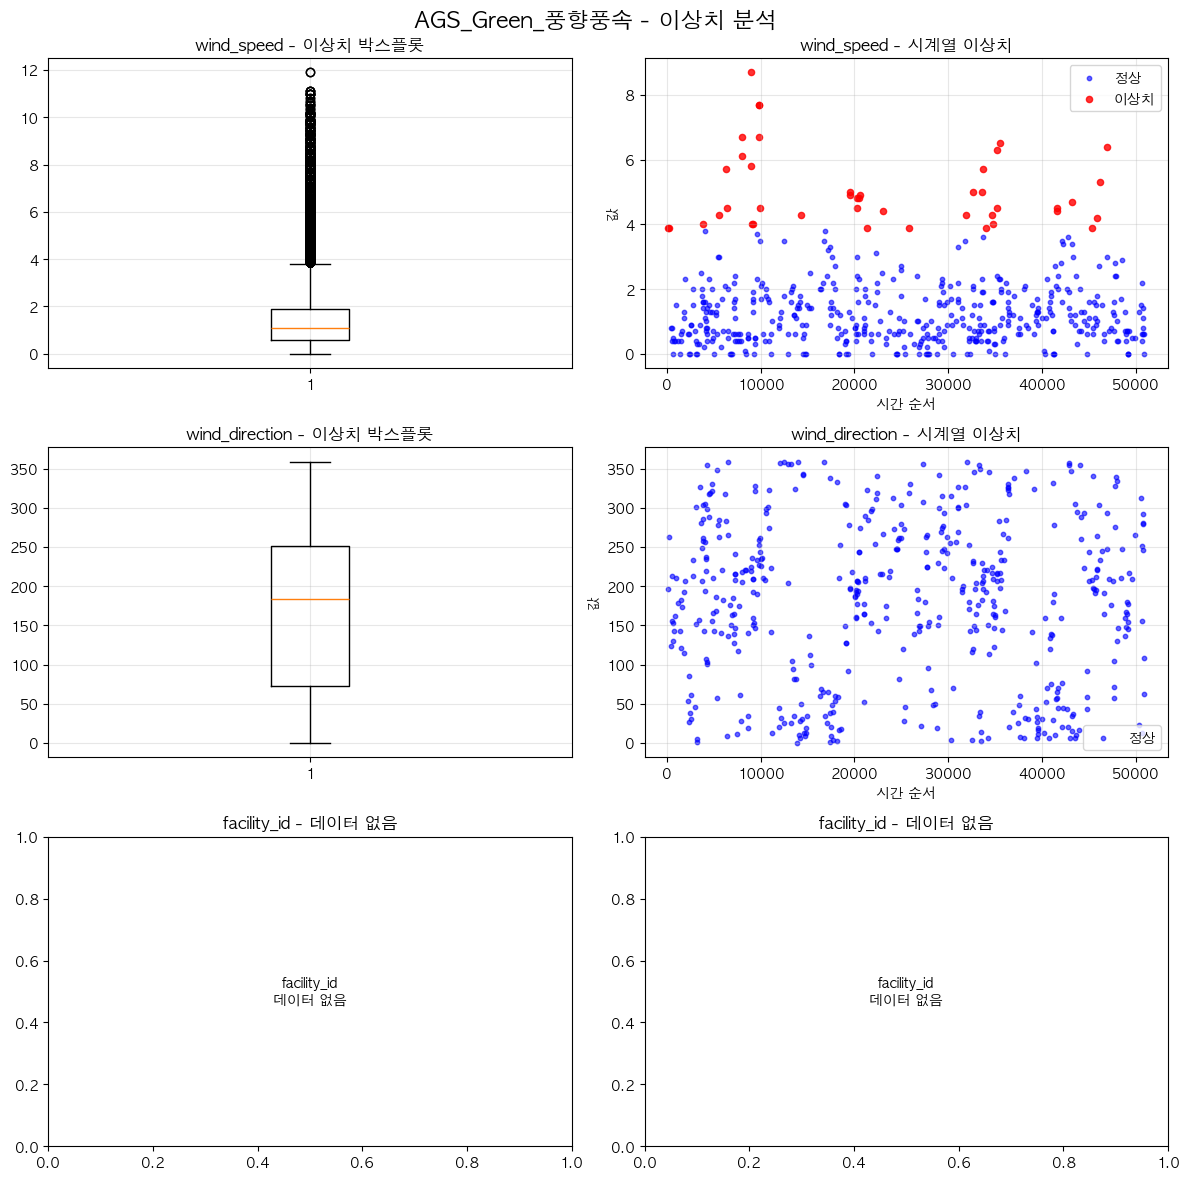

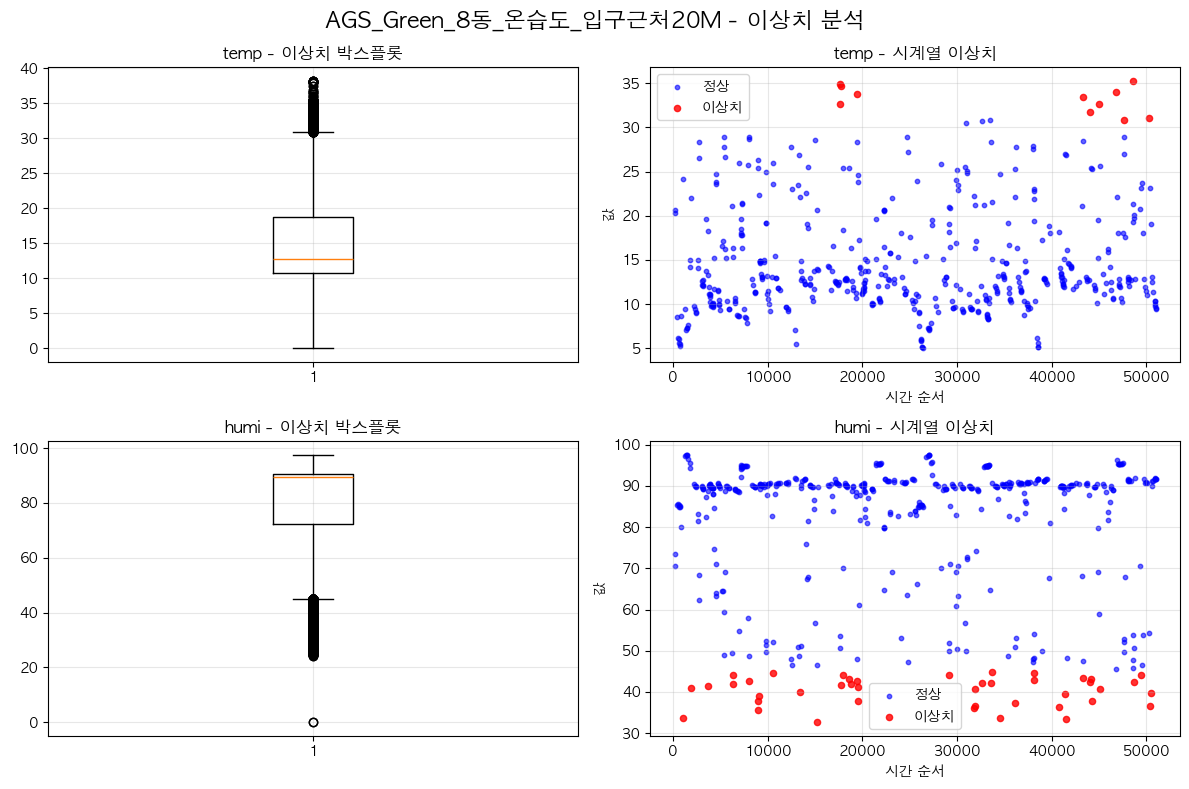

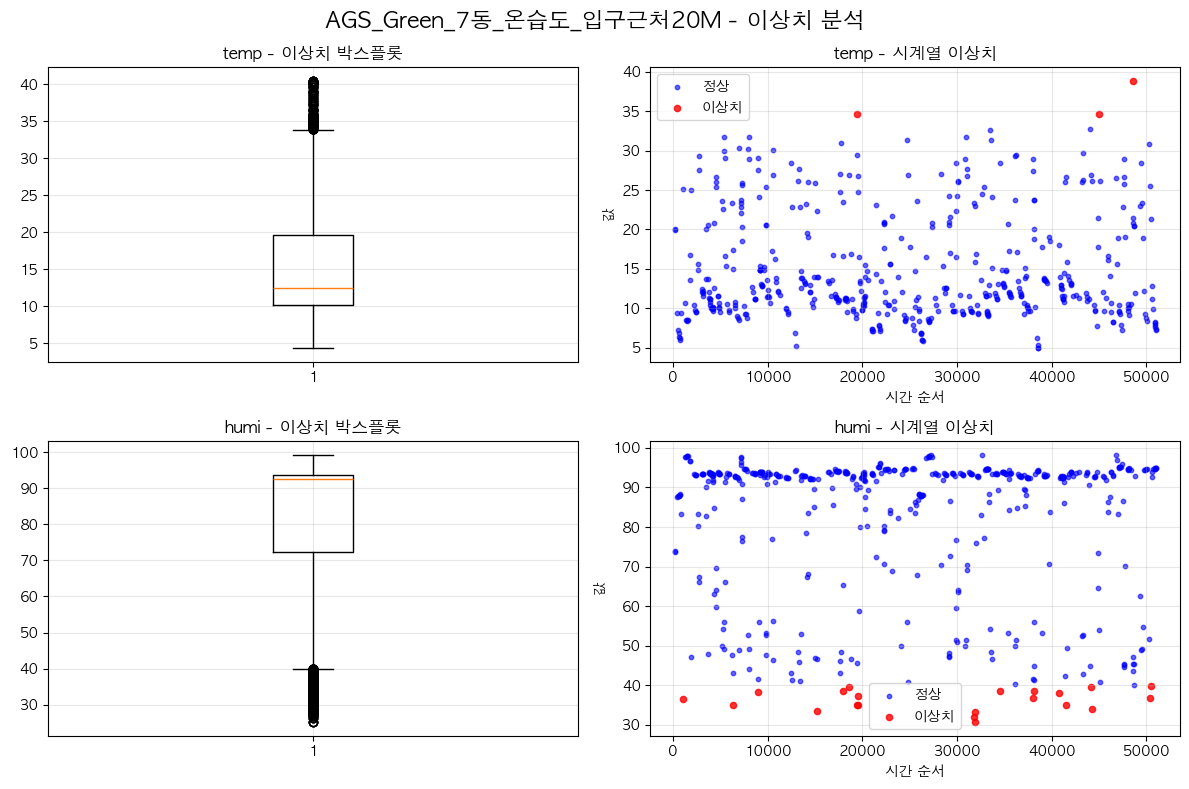

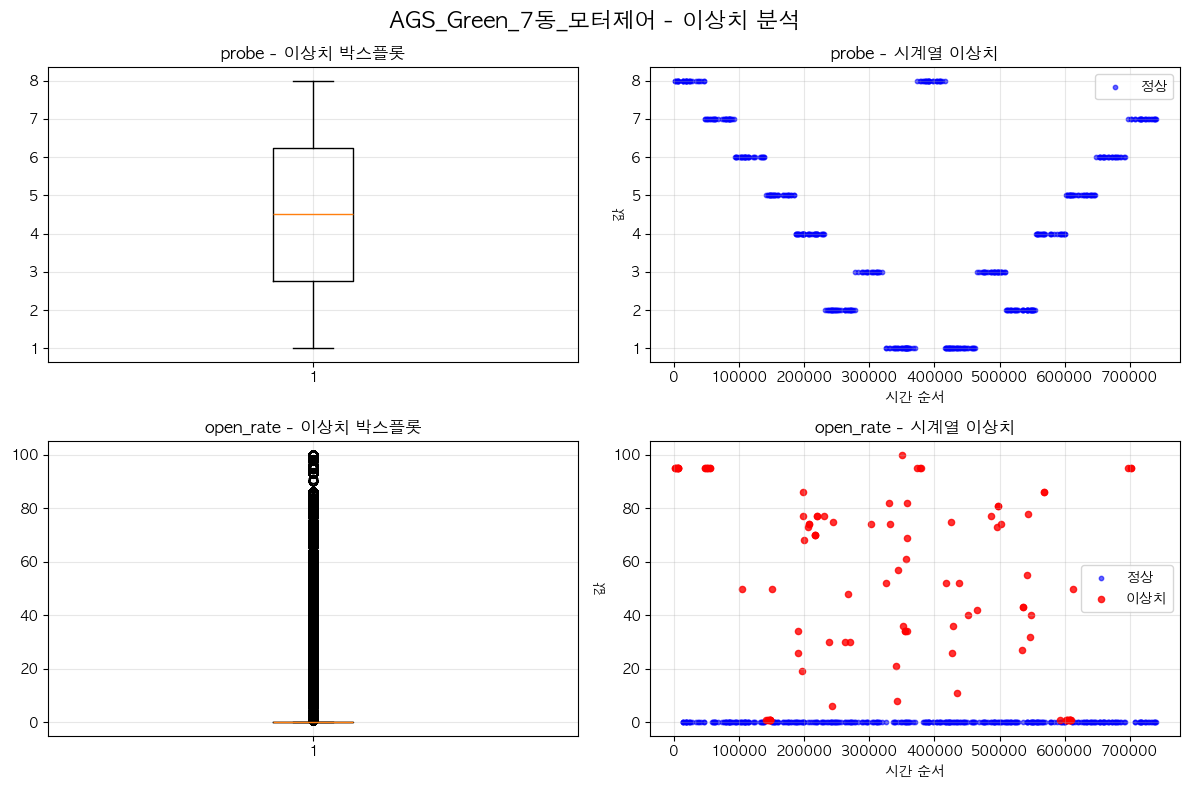

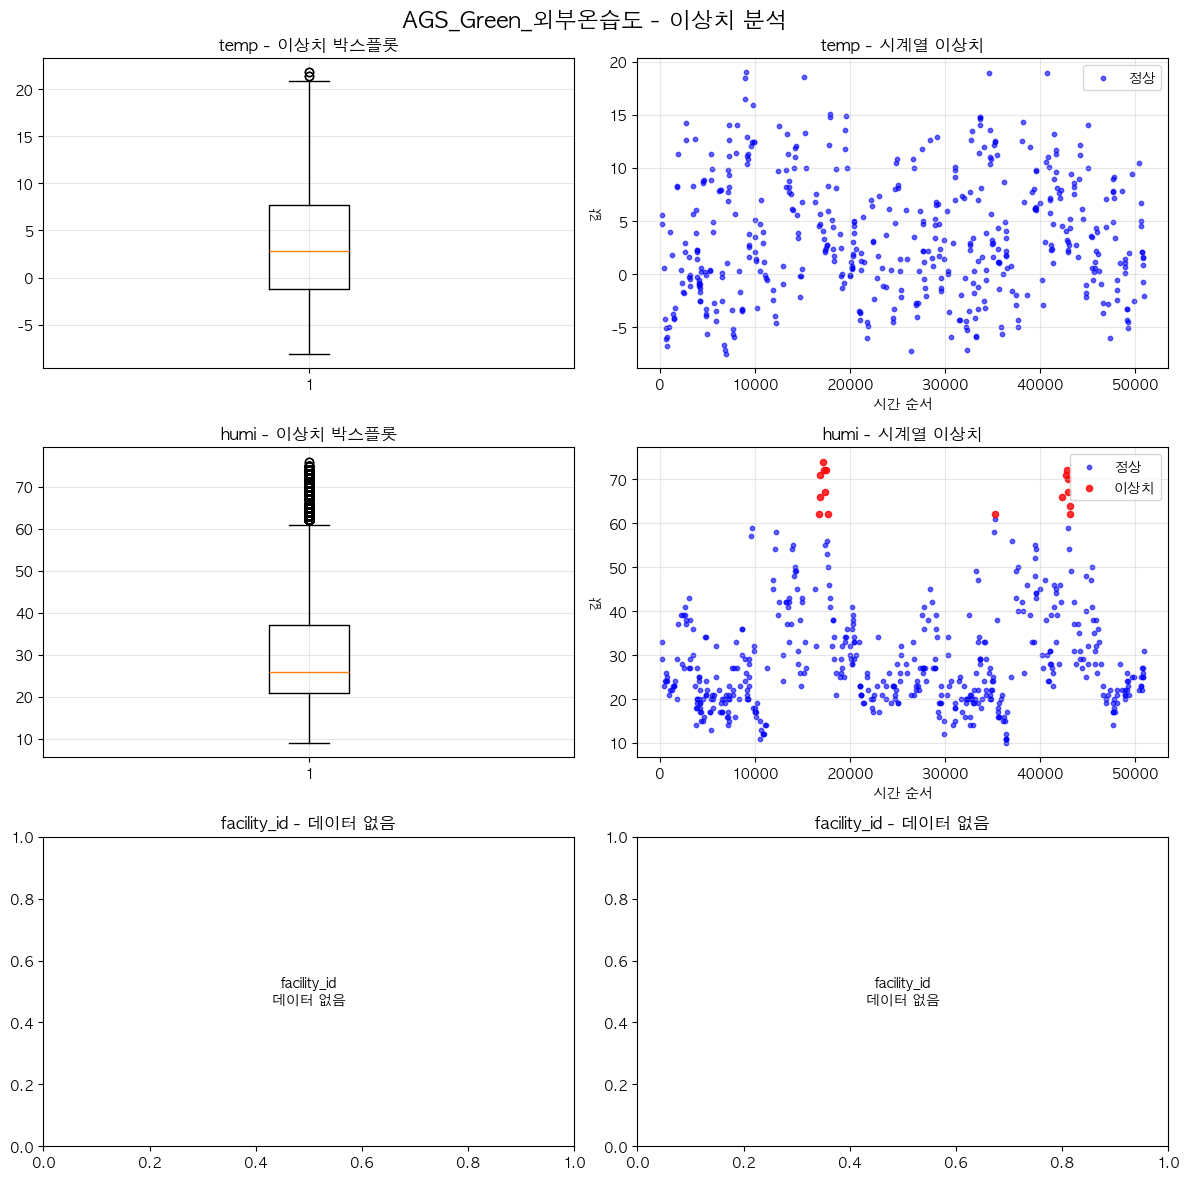

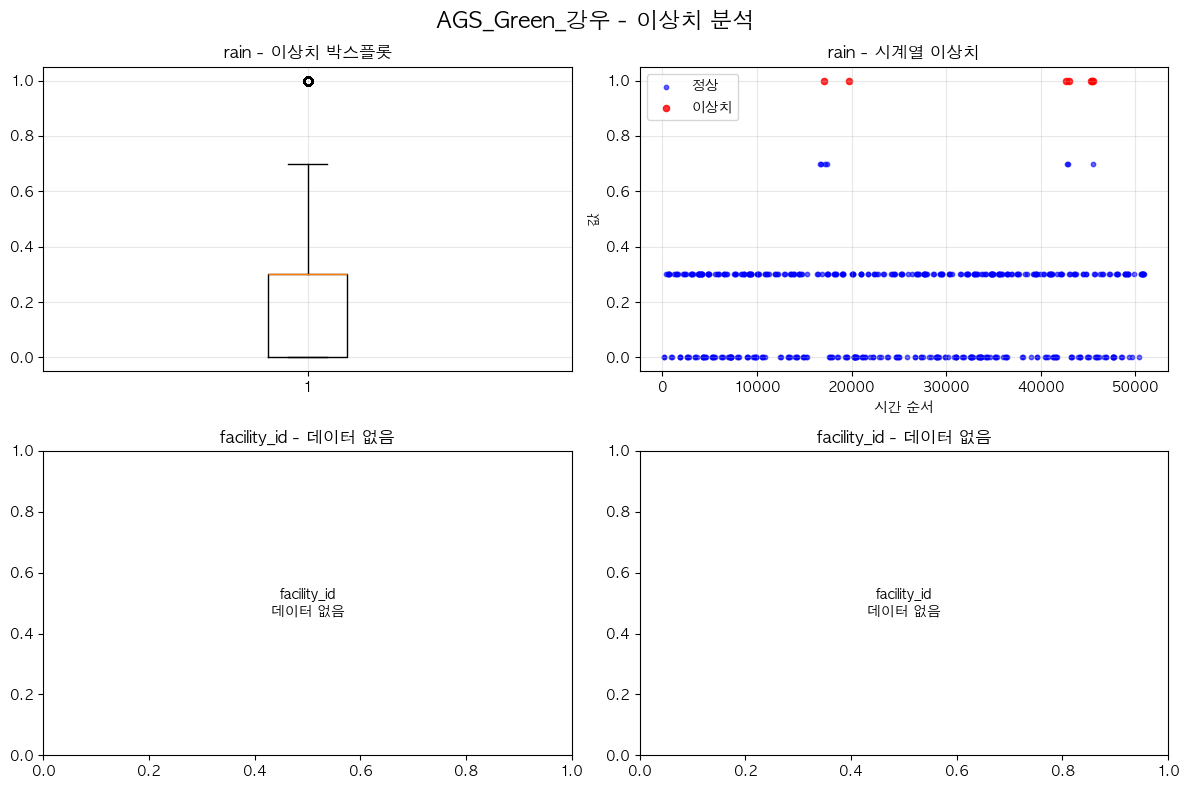

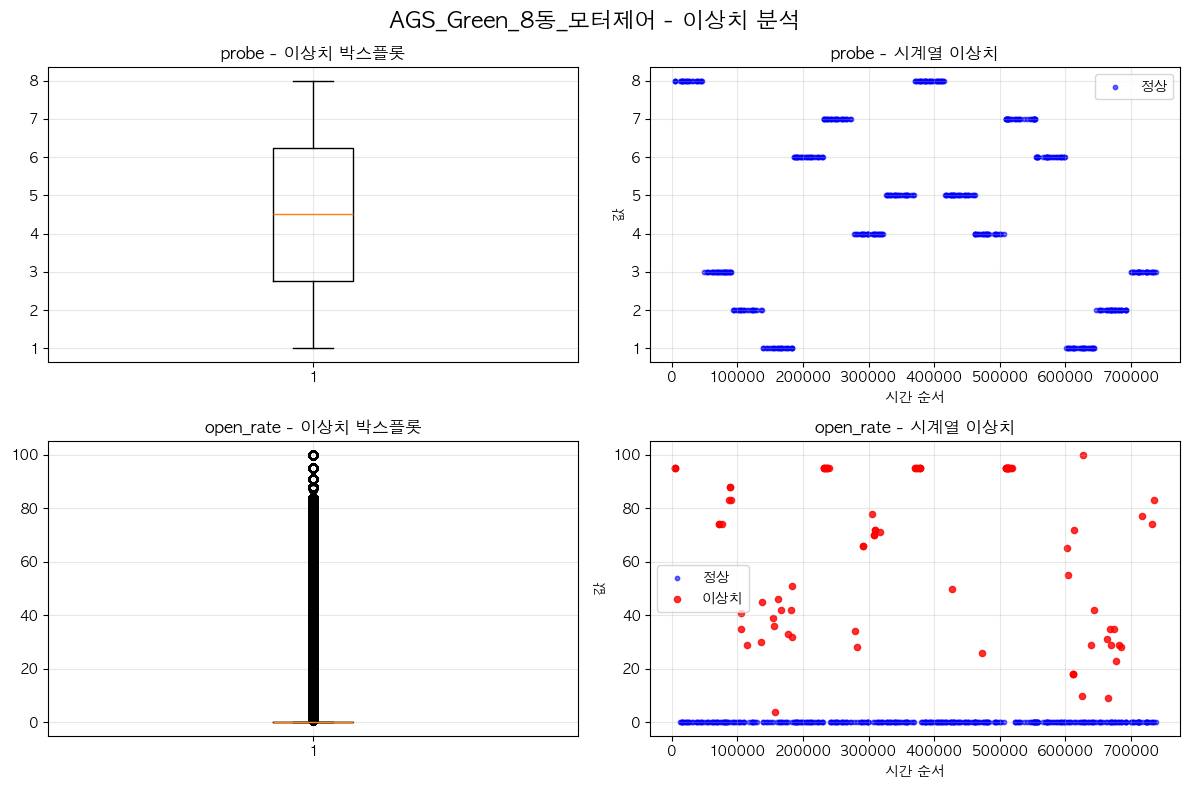


✅ 데이터 품질 분석 완료!


In [5]:
# 이상치 및 데이터 품질 분석

def analyze_data_quality(results):
    """
    데이터 품질 평가 및 이상치 상세 분석
    """
    
    print("\n" + "="*80)
    print("🔍 데이터 품질 분석")
    print("="*80)
    
    quality_report = []
    
    for sensor_name, sensor_data in results.items():
        print(f"\n🎯 {sensor_name} 품질 평가")
        print("-" * 50)
        
        total_rows = sensor_data['total_rows']
        raw_data = sensor_data['raw_data']
        
        # 전반적인 데이터 품질 지표
        total_cells = total_rows * len(sensor_data['columns'])
        total_missing = raw_data.isnull().sum().sum()
        missing_rate = (total_missing / total_cells) * 100
        
        print(f"📊 전체 품질:")
        print(f"  전체 셀 수: {total_cells:,}")
        print(f"  결측 셀 수: {total_missing:,}")
        print(f"  결측률: {missing_rate:.2f}%")
        
        # 중복 데이터 확인
        duplicates = raw_data.duplicated().sum()
        duplicate_rate = (duplicates / total_rows) * 100
        print(f"  중복 행 수: {duplicates:,}")
        print(f"  중복률: {duplicate_rate:.2f}%")
        
        # 각 컬럼별 품질 평가
        for col in sensor_data['numeric_cols']:
            col_analysis = sensor_data['analysis'][col]
            data = col_analysis['data']
            
            print(f"\n📈 {col} 품질:")
            
            # 데이터가 비어있는 경우 확인
            if len(data) == 0:
                print(f"  ⚠️ 데이터가 없어 분석을 건너뜁니다")
                continue
            
            # 이상치 상세 분석
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers = data[(data < lower_bound) | (data > upper_bound)]
            
            # 극단 이상치 (3*IQR)
            extreme_lower = Q1 - 3 * IQR
            extreme_upper = Q3 + 3 * IQR
            extreme_outliers = data[(data < extreme_lower) | (data > extreme_upper)]
            
            print(f"  이상치 (1.5*IQR): {len(outliers)}개 ({col_analysis['outliers_pct']:.2f}%)")
            
            # 극단 이상치 비율 계산 (division by zero 방지)
            extreme_outlier_pct = (len(extreme_outliers)/len(data))*100 if len(data) > 0 else 0
            print(f"  극단 이상치 (3*IQR): {len(extreme_outliers)}개 ({extreme_outlier_pct:.2f}%)")
            
            if len(outliers) > 0:
                print(f"  이상치 범위: {outliers.min():.2f} ~ {outliers.max():.2f}")
                print(f"  정상 데이터 범위: {lower_bound:.2f} ~ {upper_bound:.2f}")
            
            # 데이터 연속성 분석 (갑작스러운 변화)
            if len(data) > 1:
                diff = data.diff().abs()
                sudden_changes = diff[diff > diff.quantile(0.99)]  # 상위 1% 변화
                sudden_change_pct = (len(sudden_changes)/len(data))*100 if len(data) > 0 else 0
                print(f"  급변 데이터: {len(sudden_changes)}개 ({sudden_change_pct:.2f}%)")
            
            # 품질 등급 평가
            quality_score = 100
            quality_score -= col_analysis['missing_pct'] * 2  # 결측치 감점
            quality_score -= col_analysis['outliers_pct'] * 1  # 이상치 감점
            quality_score -= duplicate_rate * 0.5  # 중복 감점
            
            if quality_score >= 90:
                grade = "A (매우 좋음)"
            elif quality_score >= 80:
                grade = "B (좋음)"
            elif quality_score >= 70:
                grade = "C (보통)"
            elif quality_score >= 60:
                grade = "D (나쁨)"
            else:
                grade = "F (매우 나쁨)"
            
            print(f"  품질 등급: {grade} (점수: {quality_score:.1f})")
            
            quality_report.append({
                '센서': sensor_name,
                '컬럼': col,
                '품질점수': quality_score,
                '품질등급': grade,
                '결측률(%)': col_analysis['missing_pct'],
                '이상치률(%)': col_analysis['outliers_pct'],
                '중복률(%)': duplicate_rate
            })
    
    # 품질 요약 테이블
    quality_df = pd.DataFrame(quality_report)
    quality_df = quality_df.sort_values('품질점수', ascending=False)
    
    print("\n" + "="*100)
    print("📋 데이터 품질 요약")
    print("="*100)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', 20)
    display(quality_df)
    
    return quality_df

def create_outlier_visualization(results):
    """
    이상치 시각화
    """
    
    print("\n📊 이상치 시각화 생성...")
    
    for sensor_name, sensor_data in results.items():
        numeric_cols = sensor_data['numeric_cols']
        
        if not numeric_cols:
            continue
            
        n_cols = len(numeric_cols)
        fig, axes = plt.subplots(n_cols, 2, figsize=(12, 4*n_cols))
        if n_cols == 1:
            axes = axes.reshape(1, -1)
        
        fig.suptitle(f'{sensor_name} - 이상치 분석', fontsize=16, fontweight='bold')
        
        for i, col in enumerate(numeric_cols):
            data = sensor_data['analysis'][col]['data']
            raw_data = sensor_data['raw_data']
            
            # 데이터가 비어있는 경우 확인
            if len(data) == 0:
                axes[i, 0].text(0.5, 0.5, f'{col}\n데이터 없음', 
                               ha='center', va='center', transform=axes[i, 0].transAxes)
                axes[i, 0].set_title(f'{col} - 데이터 없음')
                axes[i, 1].text(0.5, 0.5, f'{col}\n데이터 없음', 
                               ha='center', va='center', transform=axes[i, 1].transAxes)
                axes[i, 1].set_title(f'{col} - 데이터 없음')
                continue
            
            # 1. 이상치 포함 박스플롯
            axes[i, 0].boxplot(data, vert=True)
            axes[i, 0].set_title(f'{col} - 이상치 박스플롯')
            axes[i, 0].grid(True, alpha=0.3)
            
            # 2. 시계열상 이상치 표시
            if len(raw_data) > 500:
                sample_data = raw_data.sample(500, random_state=42).sort_values('ts')
            else:
                sample_data = raw_data.sort_values('ts')
            
            # 이상치 계산
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # 정상 데이터와 이상치 분리
            normal_mask = (sample_data[col] >= lower_bound) & (sample_data[col] <= upper_bound)
            outlier_mask = ~normal_mask
            
            # 정상 데이터 플롯
            axes[i, 1].scatter(sample_data[normal_mask].index, 
                             sample_data[normal_mask][col], 
                             c='blue', alpha=0.6, s=10, label='정상')
            
            # 이상치 플롯
            if outlier_mask.any():
                axes[i, 1].scatter(sample_data[outlier_mask].index, 
                                 sample_data[outlier_mask][col], 
                                 c='red', alpha=0.8, s=20, label='이상치')
            
            axes[i, 1].set_title(f'{col} - 시계열 이상치')
            axes[i, 1].set_xlabel('시간 순서')
            axes[i, 1].set_ylabel('값')
            axes[i, 1].legend()
            axes[i, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# 데이터 품질 분석 실행
quality_df = analyze_data_quality(results)
create_outlier_visualization(results)

print("\n✅ 데이터 품질 분석 완료!")

In [6]:
# 최종 요약 및 인사이트 도출

def generate_final_insights(results, quality_df):
    """
    모든 분석 결과를 종합하여 최종 인사이트 도출
    """
    
    print("\n" + "="*100)
    print("🎯 최종 분석 요약 및 인사이트")
    print("="*100)
    
    # 1. 전체 데이터 현황
    total_sensors = len(results)
    total_files = sum(len([f for f in os.listdir(os.path.join("/Users/jeong-won-il/workspace/SDF/train/pipeline_output/organized_by_sensor", sensor)) 
                         if f.endswith('.csv')]) for sensor in results.keys())
    total_rows = sum(sensor_data['total_rows'] for sensor_data in results.values())
    
    print(f"\n📊 전체 현황:")
    print(f"  센서 종류: {total_sensors}개")
    print(f"  전체 파일: {total_files}개")
    print(f"  전체 데이터: {total_rows:,}행")
    
    # 2. 센서 유형별 특성
    sensor_types = {}
    for sensor_name in results.keys():
        if '모터제어' in sensor_name:
            sensor_type = '모터제어'
        elif '온습도' in sensor_name:
            sensor_type = '온습도'
        elif '강우' in sensor_name:
            sensor_type = '강우'
        elif '풍향풍속' in sensor_name:
            sensor_type = '풍향풍속'
        elif '외부온습도' in sensor_name:
            sensor_type = '외부온습도'
        else:
            sensor_type = '기타'
        
        sensor_types[sensor_type] = sensor_types.get(sensor_type, 0) + 1
    
    print(f"\n🏷️ 센서 유형별 분포:")
    for sensor_type, count in sensor_types.items():
        print(f"  {sensor_type}: {count}개")
    
    # 3. 데이터 품질 현황
    print(f"\n📈 데이터 품질 현황:")
    quality_summary = quality_df['품질등급'].value_counts()
    for grade, count in quality_summary.items():
        pct = (count / len(quality_df)) * 100
        print(f"  {grade}: {count}개 ({pct:.1f}%)")
    
    avg_quality_score = quality_df['품질점수'].mean()
    print(f"  평균 품질 점수: {avg_quality_score:.1f}")
    
    # 4. 주요 이슈 식별
    print(f"\n⚠️ 주요 이슈:")
    
    # 높은 결측치율
    high_missing = quality_df[quality_df['결측률(%)'] > 5]
    if len(high_missing) > 0:
        print(f"  🔸 높은 결측치율 (>5%): {len(high_missing)}개 컬럼")
        for _, row in high_missing.iterrows():
            print(f"    - {row['센서']}/{row['컬럼']}: {row['결측률(%)']:.1f}%")
    
    # 높은 이상치율
    high_outliers = quality_df[quality_df['이상치률(%)'] > 10]
    if len(high_outliers) > 0:
        print(f"  🔸 높은 이상치율 (>10%): {len(high_outliers)}개 컬럼")
        for _, row in high_outliers.iterrows():
            print(f"    - {row['센서']}/{row['컬럼']}: {row['이상치률(%)']:.1f}%")
    
    # 낮은 품질 등급
    low_quality = quality_df[quality_df['품질점수'] < 70]
    if len(low_quality) > 0:
        print(f"  🔸 낮은 품질 등급 (<70점): {len(low_quality)}개 컬럼")
        for _, row in low_quality.iterrows():
            print(f"    - {row['센서']}/{row['컬럼']}: {row['품질점수']:.1f}점 ({row['품질등급']})")
    
    # 5. 센서별 특성 요약
    print(f"\n🔍 센서별 특성 요약:")
    for sensor_name, sensor_data in results.items():
        print(f"\n  📡 {sensor_name}:")
        
        # 주요 측정값
        numeric_cols = sensor_data['numeric_cols']
        if numeric_cols:
            print(f"    주요 측정값: {', '.join(numeric_cols)}")
            
            # 각 측정값의 특성
            for col in numeric_cols:
                col_analysis = sensor_data['analysis'][col]
                stats = col_analysis['stats']
                
                # 데이터 범위 특성
                range_ratio = (stats['max'] - stats['min']) / stats['mean'] if stats['mean'] != 0 else 0
                
                if range_ratio < 0.1:
                    range_char = "매우 안정적"
                elif range_ratio < 0.5:
                    range_char = "안정적"
                elif range_ratio < 1.0:
                    range_char = "보통"
                else:
                    range_char = "변동성 큼"
                
                print(f"      {col}: 평균 {stats['mean']:.2f}, 범위 {range_char}")
    
    # 6. 개선 권고사항
    print(f"\n💡 개선 권고사항:")
    
    recommendations = []
    
    # 결측치 처리 권고
    if len(high_missing) > 0:
        recommendations.append("결측치가 많은 데이터에 대해 보간법 또는 제거 전략 수립 필요")
    
    # 이상치 처리 권고
    if len(high_outliers) > 0:
        recommendations.append("이상치가 많은 데이터에 대해 원인 분석 및 처리 방안 검토 필요")
    
    # 데이터 규칙성 권고
    irregular_sensors = []
    for sensor_name, sensor_data in results.items():
        raw_data = sensor_data['raw_data'].copy()
        try:
            # datetime 파싱 오류 수정
            raw_data['ts'] = pd.to_datetime(raw_data['ts'], format='mixed')
        except:
            try:
                raw_data['ts'] = pd.to_datetime(raw_data['ts'], format='ISO8601')
            except:
                raw_data['ts'] = pd.to_datetime(raw_data['ts'], errors='coerce')
        
        time_diffs = raw_data['ts'].diff().dt.total_seconds().dropna()
        cv = (time_diffs.std() / time_diffs.mean()) if time_diffs.mean() != 0 else 0
        if cv > 0.1:  # 변동계수 10% 초과
            irregular_sensors.append(sensor_name)
    
    if irregular_sensors:
        recommendations.append(f"불규칙한 수집 간격을 보이는 센서: {', '.join(irregular_sensors[:3])}{' 등' if len(irregular_sensors) > 3 else ''}")
    
    # 품질 개선 권고
    if avg_quality_score < 80:
        recommendations.append("전반적인 데이터 품질 개선을 위한 데이터 수집 프로세스 검토 필요")
    
    if recommendations:
        for i, rec in enumerate(recommendations, 1):
            print(f"  {i}. {rec}")
    else:
        print("  ✅ 현재 데이터 상태가 양호함")
    
    # 7. 다음 분석 단계 제안
    print(f"\n🚀 다음 분석 단계 제안:")
    print(f"  1. 시계열 분석: 추세, 계절성, 주기성 파악")
    print(f"  2. 센서 간 상관관계 분석: 연관성 있는 센서 그룹핑")
    print(f"  3. 이상 감지 모델링: 실시간 이상 데이터 탐지 시스템")
    print(f"  4. 예측 모델링: 센서 데이터 기반 예측 모델 개발")
    print(f"  5. 데이터 전처리 파이프라인: 자동화된 데이터 정제 시스템")

# 최종 인사이트 실행
generate_final_insights(results, quality_df)

print("\n" + "="*100)
print("🎉 전체 분석 완료!")
print("="*100)


🎯 최종 분석 요약 및 인사이트

📊 전체 현황:
  센서 종류: 7개
  전체 파일: 42개
  전체 데이터: 1,735,382행

🏷️ 센서 유형별 분포:
  풍향풍속: 1개
  온습도: 3개
  모터제어: 2개
  강우: 1개

📈 데이터 품질 현황:
  C (보통): 9개 (69.2%)
  D (나쁨): 2개 (15.4%)
  F (매우 나쁨): 2개 (15.4%)
  평균 품질 점수: 70.2

⚠️ 주요 이슈:
  🔸 높은 이상치율 (>10%): 2개 컬럼
    - AGS_Green_8동_모터제어/open_rate: 16.2%
    - AGS_Green_7동_모터제어/open_rate: 18.6%
  🔸 낮은 품질 등급 (<70점): 4개 컬럼
    - AGS_Green_풍향풍속/wind_speed: 67.6점 (D (나쁨))
    - AGS_Green_8동_온습도_입구근처20M/humi: 67.0점 (D (나쁨))
    - AGS_Green_8동_모터제어/open_rate: 58.8점 (F (매우 나쁨))
    - AGS_Green_7동_모터제어/open_rate: 56.4점 (F (매우 나쁨))

🔍 센서별 특성 요약:

  📡 AGS_Green_풍향풍속:
    주요 측정값: wind_speed, wind_direction, facility_id
      wind_speed: 평균 1.47, 범위 변동성 큼
      wind_direction: 평균 172.60, 범위 변동성 큼
      facility_id: 평균 nan, 범위 변동성 큼

  📡 AGS_Green_8동_온습도_입구근처20M:
    주요 측정값: temp, humi
      temp: 평균 15.06, 범위 변동성 큼
      humi: 평균 79.91, 범위 변동성 큼

  📡 AGS_Green_7동_온습도_입구근처20M:
    주요 측정값: temp, humi
      temp: 평균 15.10, 범위 변동성 큼
      humi: 평균 81.